### MLP Model made using PyTorch
Relevant Statistics: Made via MLP with 5 layers 1024->output

| Category        | Accuracy  | Precision | Recall   | F1      |
|-----------------|-----------|-----------|----------|---------|
| any             | 0.837519  | 0.803354  | 0.798485 | 0.800912|
| epidural        | 0.621705  | 0.027375  | 0.739130 | 0.052795|
| intraparenchymal| 0.733643  | 0.478357  | 0.815000 | 0.602866|
| intraventricular| 0.684651  | 0.333089  | 0.811052 | 0.472237|
| subarachnoid    | 0.692713  | 0.360354  | 0.799020 | 0.496699|
| subdural        | 0.683411  | 0.341322  | 0.804795 | 0.479347|

AUC overall: 0.83

In [1]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader


In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../Sino_CT.csv')

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Map the 'label' column to 0 for abnormal ('0,1') and 1 for normal ('1,0')
df['label'] = df['label'].apply(lambda x: 1 if x == '1,0' else 0)

# Define the target column
target_column = 'label'

# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_column].values.astype(np.float32)

# Reshape y to be (n_samples, 1) for consistency with the model output
y = y.reshape(-1, 1)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Data loaded and preprocessed successfully.")
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

Data loaded and preprocessed successfully.
X_train_tensor shape: torch.Size([5464, 1408])
y_train_tensor shape: torch.Size([5464, 1])


In [14]:
# Define an Early Stopping class

class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

In [26]:
# Define the MLP model with optimal hyperparameters for binary classification

class SinoMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(SinoMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.fc3 = nn.Linear(512, 256)
        self.bn3 = nn.BatchNorm1d(256)
        self.fc4 = nn.Linear(256, 128)
        self.bn4 = nn.BatchNorm1d(128)
        self.fc5 = nn.Linear(128, output_size)
        self.relu = nn.ReLU()

        # Dropout layers with increasing dropout rates
        self.dropout1 = nn.Dropout(0.1)
        self.dropout2 = nn.Dropout(0.2)
        self.dropout3 = nn.Dropout(0.3)
        self.dropout4 = nn.Dropout(0.4)


    def forward(self, x):
        # First layer with minimal dropout
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        # Hidden layers with increasing dropout
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        
        x = self.relu(self.bn4(self.fc4(x)))
        
        # Output layer (no activation, will use BCEWithLogitsLoss)
        x = self.fc5(x)
        return x

In [ ]:
# Define a training loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SinoMLP(input_size=X_train_tensor.shape[1], output_size=1).to(device)
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-3)
early_stopper = EarlyStopping(patience=5)

# Train the model using 50 epochs with early stopping
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = model(xb)
            loss = criterion(output, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(test_loader.dataset)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    early_stopper(val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered.")
        break

Epoch 1: Train Loss=0.5051, Val Loss=0.4960
Epoch 2: Train Loss=0.4885, Val Loss=0.5037
Epoch 2: Train Loss=0.4885, Val Loss=0.5037
Epoch 3: Train Loss=0.4833, Val Loss=0.4950
Epoch 3: Train Loss=0.4833, Val Loss=0.4950
Epoch 4: Train Loss=0.4779, Val Loss=0.5010
Epoch 4: Train Loss=0.4779, Val Loss=0.5010
Epoch 5: Train Loss=0.4755, Val Loss=0.5036
Epoch 5: Train Loss=0.4755, Val Loss=0.5036


In [19]:
from sklearn.metrics import accuracy_score

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        output = model(xb)
        preds = (torch.sigmoid(output) > 0.5).cpu().numpy()
        y_true.append(yb.numpy())
        y_pred.append(preds)
y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)
print("Test accuracy (any class):", accuracy_score(y_true[:,0], y_pred[:,0]))

Test accuracy (any class): 0.7401171303074671


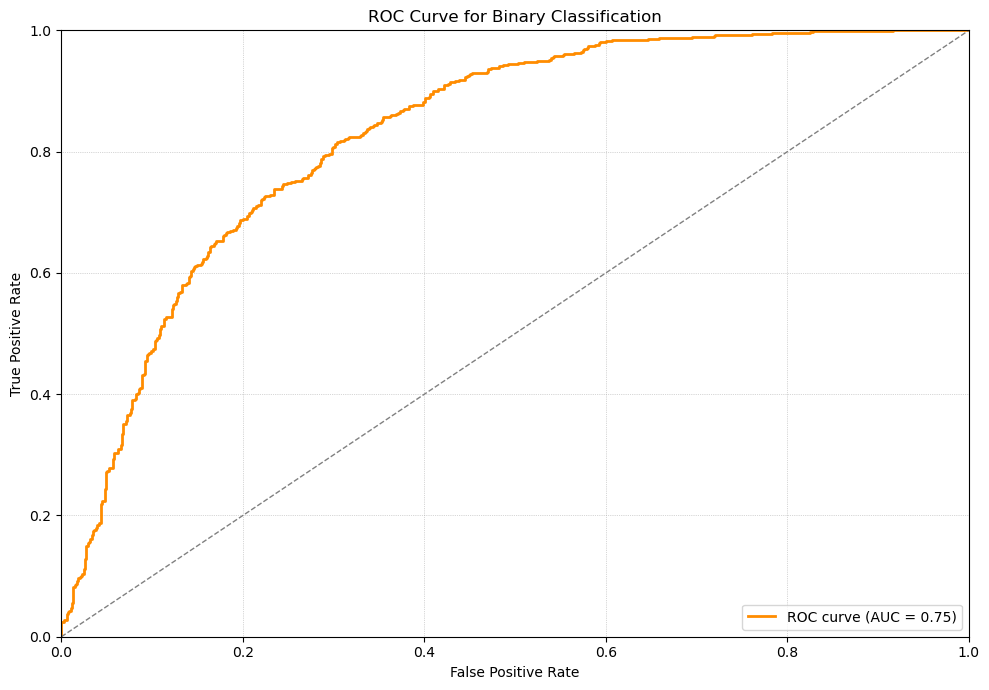

In [24]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get model predictions and probabilities
model.eval()
y_true = []
y_pred_prob = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        output = model(xb)
        prob = torch.sigmoid(output)
        y_true.append(yb.numpy())
        y_pred_prob.append(prob.cpu().numpy())

y_true = np.vstack(y_true)
y_pred_prob = np.vstack(y_pred_prob)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = roc_auc_score(y_true, y_pred)

# Plot ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Binary Classification')
plt.legend(loc='lower right')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, ls=':', lw=0.5)
plt.tight_layout()
plt.show()


Model Performance Metrics:
Accuracy: 0.7467
Precision: 0.7275
Recall: 0.7793
F1 Score: 0.7525


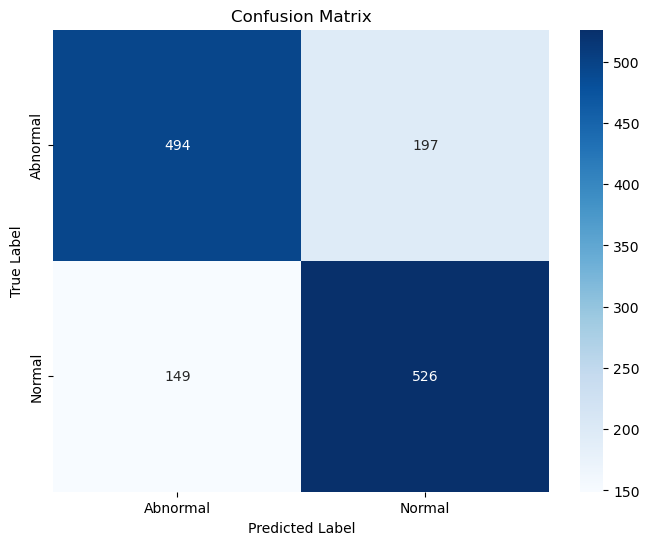

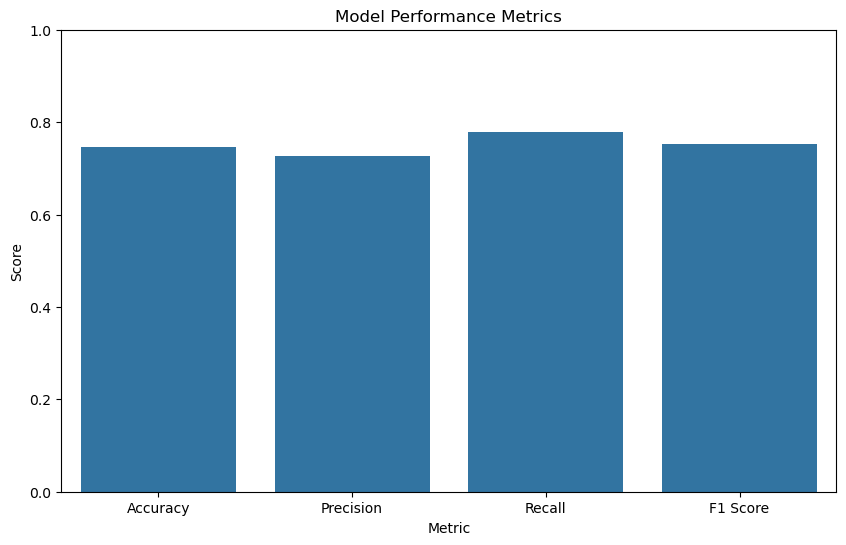

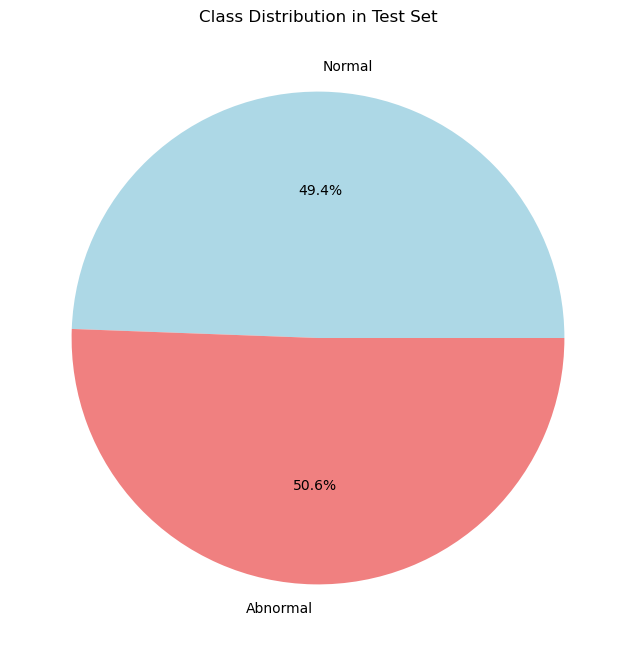

In [25]:
# Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['Abnormal', 'Normal']

# Plot confusion matrix with labels
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Create a bar plot of the metrics
metrics_dict = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
}
metrics_df = pd.DataFrame(metrics_dict)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', data=metrics_df)
plt.title('Model Performance Metrics')
plt.ylim(0, 1)
plt.show()

# Calculate class distribution
total_samples = len(y_true)
normal_samples = np.sum(y_true == 1)
abnormal_samples = np.sum(y_true == 0)

# Create pie chart of class distribution
plt.figure(figsize=(8, 8))
plt.pie([normal_samples, abnormal_samples], 
        labels=['Normal', 'Abnormal'],
        autopct='%1.1f%%',
        colors=['lightblue', 'lightcoral'])
plt.title('Class Distribution in Test Set')
plt.show()